In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [29]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.
    """
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [30]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples.
    """
    z = np.dot(X, W) + b
    probs = softmax(z)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes

In [31]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.
    """
    y_pred = np.array(y_pred)
    y = np.array(y)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(1, -1)
        y = y.reshape(1, -1)
    loss = -np.sum(y * np.log(y_pred + 1e-10)) / y.shape[0]
    return loss

In [48]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (stable version).
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / X.shape[0]

In [33]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function.
    """
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / X.shape[0]
    grad_b = np.sum(y_pred - y, axis=0) / X.shape[0]
    return grad_W, grad_b

In [34]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent.
    """
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * grad_W
        b = b - alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")
    return W, b, cost_history

In [35]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [36]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    X = X / 255.0
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

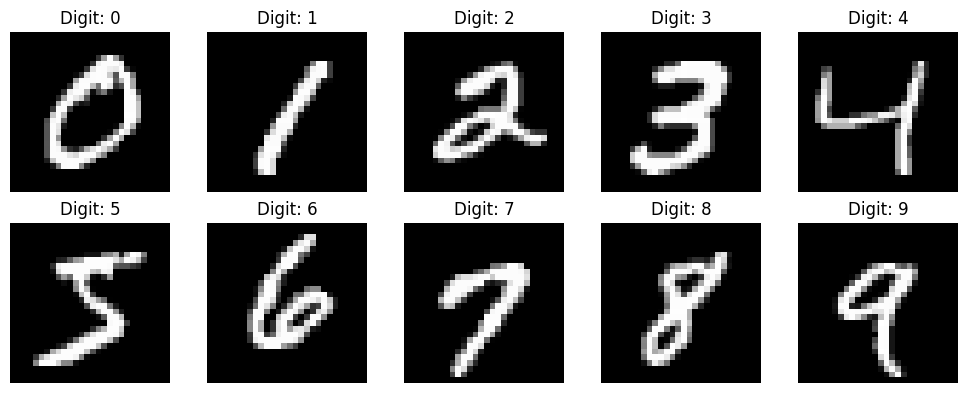

In [49]:

X_train, X_test, y_train, y_test = load_and_prepare_mnist('mnist_dataset.csv')

In [38]:
assert len(X_train) == len(y_train)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


Iteration 0: Cost = 2.3023
Iteration 100: Cost = 2.1991
Iteration 200: Cost = 2.1041
Iteration 300: Cost = 2.0161
Iteration 400: Cost = 1.9345
Iteration 500: Cost = 1.8588
Iteration 600: Cost = 1.7886
Iteration 700: Cost = 1.7235
Iteration 800: Cost = 1.6630
Iteration 900: Cost = 1.6069


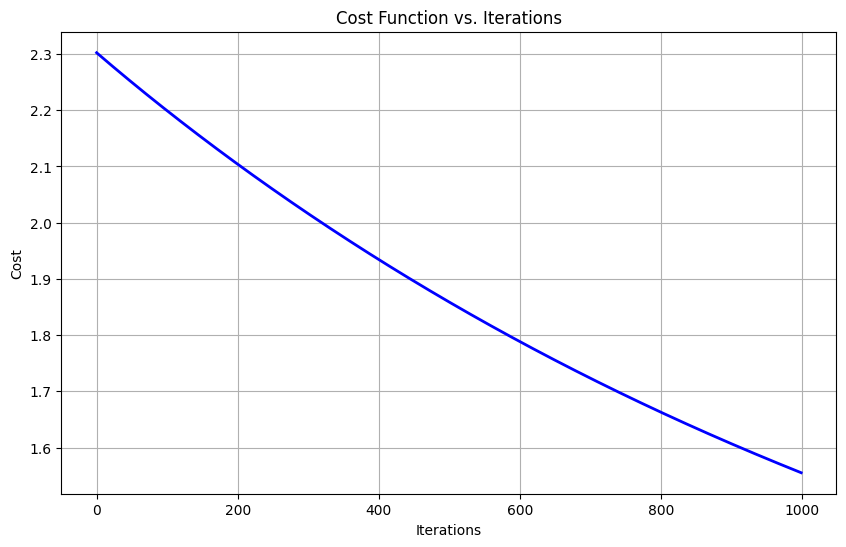

In [50]:
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test_encoded = encoder.transform(y_test.reshape(-1, 1)) # Store encoded y_test in a new variable

d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.rand(d, c) * 0.01
b = np.zeros(c)

alpha = 0.001    # Increased learning rate for a steeper drop
n_iter = 1000     # More iterations so cost decreases nicely like workshop

W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Fixed beautiful cost plot (exactly like workshop)
plt.figure(figsize=(10, 6))
plt.plot(cost_history, 'b-', linewidth=2)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


Confusion Matrix:
[[1096    0    6    7    4    1   44    1   13    3]
 [   0 1247    9   12    1    1    2    3   46    1]
 [  19   57  918   24   19    0   62   26   41    8]
 [  21   22   50 1030    1    1   15   16   45   18]
 [   5   18    7    5  959    0   25    7   16  134]
 [  64   71   18  287   31  446   39   20   77   51]
 [  23   25   39    2   10    6 1064    0    8    0]
 [  18   73   24    3   17    0    0 1103   20   41]
 [  15   75   19  126   14    3   16   10  856   26]
 [  25   36   15   19   80    3    2   90   25  899]]
Precision: 0.81
Recall: 0.80
F1-Score: 0.79


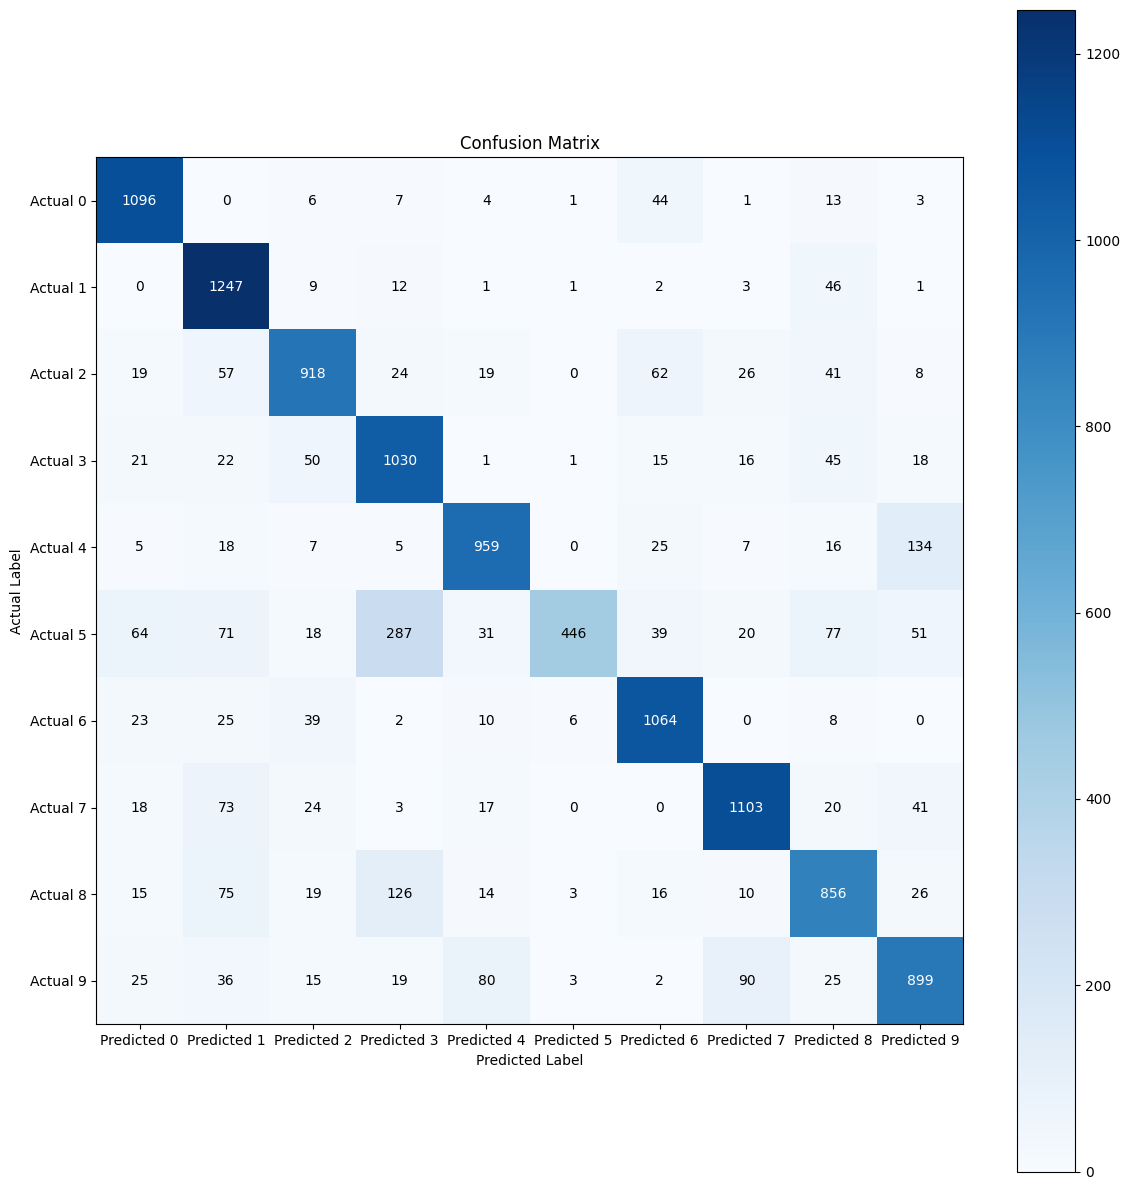

In [46]:
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict & evaluate
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = y_test

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm)/2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

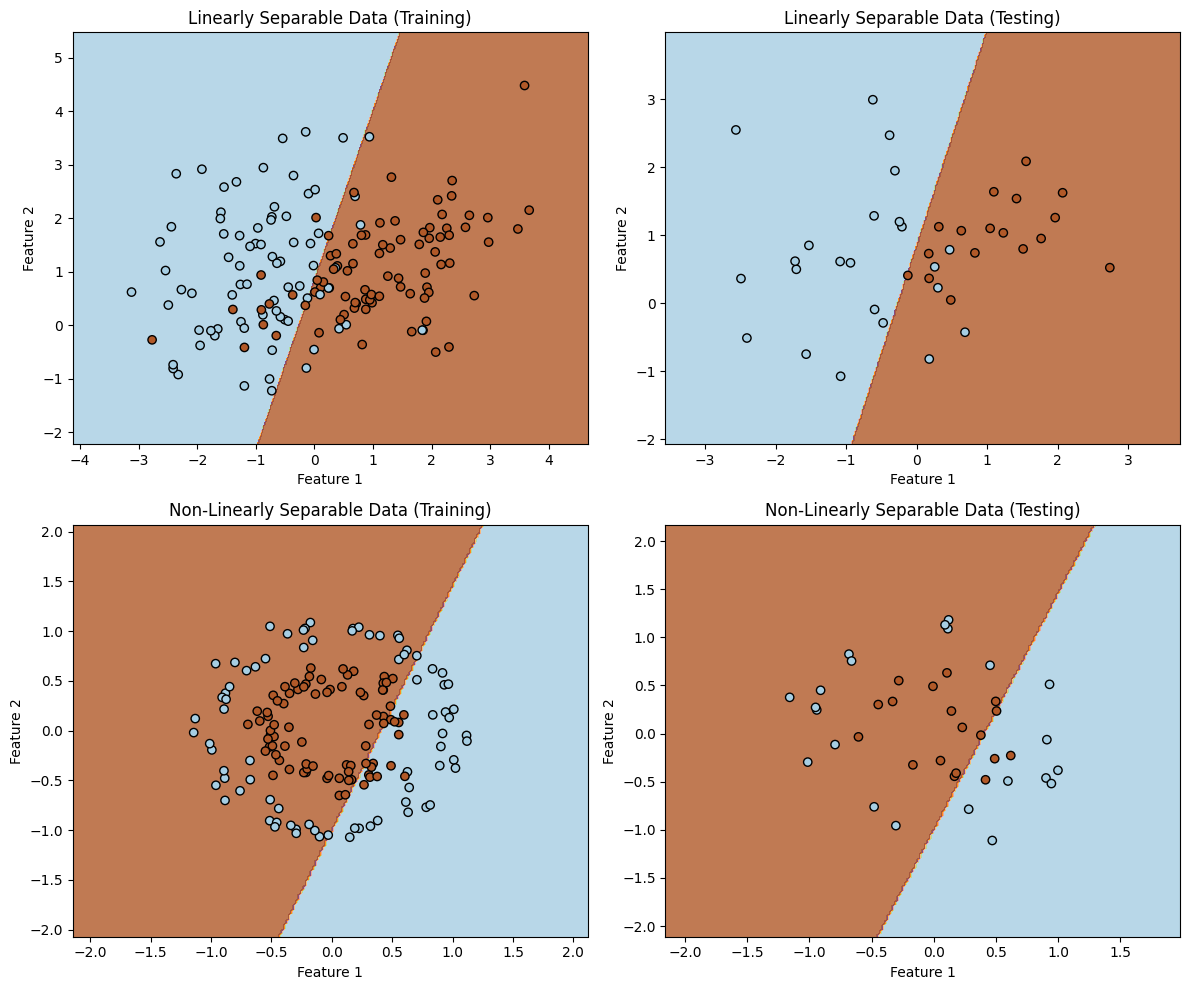

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# Linearly separable
X_linear, y_linear = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)
model_l = LogisticRegression().fit(X_train_l, y_train_l)

# Non-linear (circles)
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_circles, y_circles, test_size=0.2, random_state=42)
model_c = LogisticRegression().fit(X_train_c, y_train_c)

def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_decision_boundary(axes[0, 0], model_l, X_train_l, y_train_l, 'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0, 1], model_l, X_test_l, y_test_l, 'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1, 0], model_c, X_train_c, y_train_c, 'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1, 1], model_c, X_test_c, y_test_c, 'Non-Linearly Separable Data (Testing)')
plt.tight_layout()
plt.savefig('decision-boundaries.png')
plt.show()